In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

In [12]:
diabetes = load_diabetes()

diabetes_df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
diabetes_df['target'] = diabetes.target

In [13]:
# 데이터 익명처리됨.
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


age       0.187889
sex       0.043062
bmi       0.586450
bp        0.441482
s1        0.212022
s2        0.174054
s3       -0.394789
s4        0.430453
s5        0.565883
s6        0.382483
target    1.000000
Name: target, dtype: float64

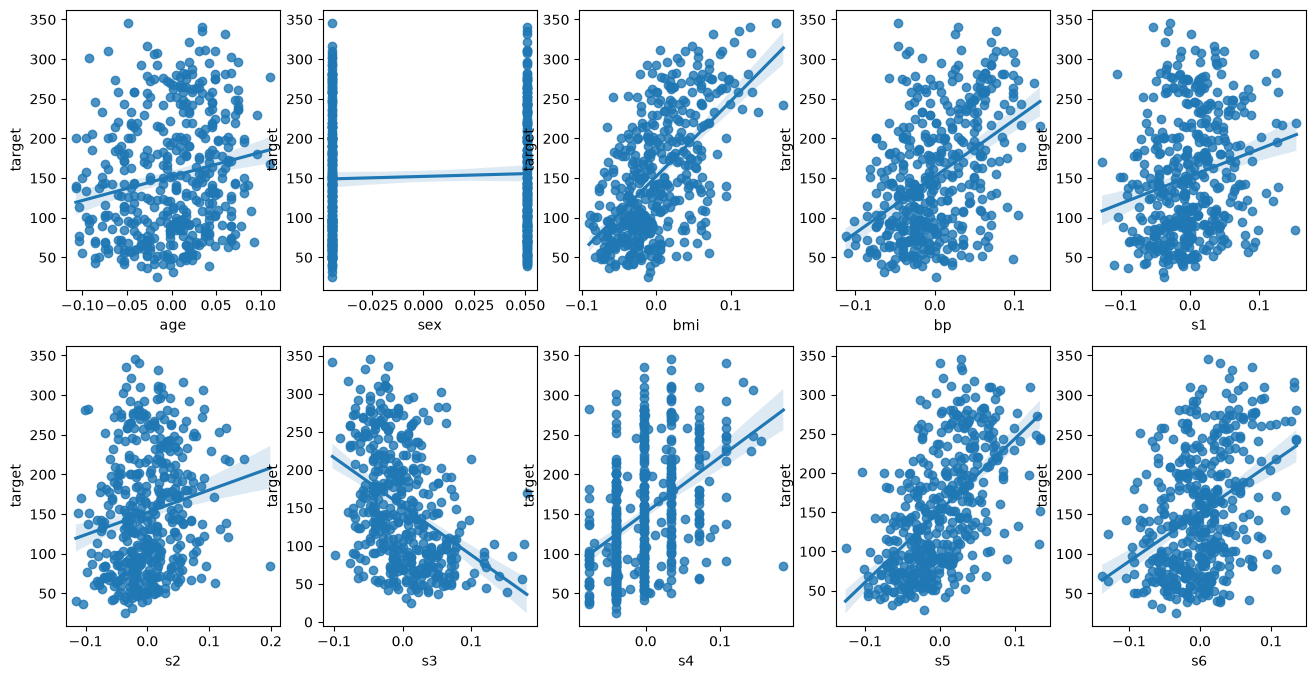

In [14]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=5, nrows=2)
lm_features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

for i, feature in enumerate(lm_features):
    row = int(i/5)
    col = i%5
    sns.regplot(x=feature, y='target', data=diabetes_df, ax=axs[row][col])

diabetes_df.corr()['target']

<Axes: xlabel='sex', ylabel='target'>

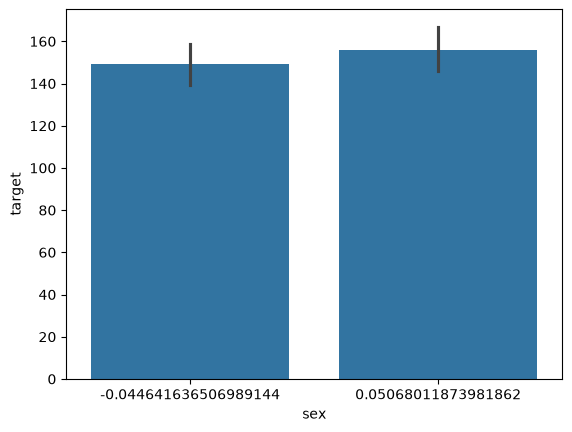

In [15]:
# 보통 성별이 수치형으로 변경될 경우,
# Female이 Male보다 알파벳적으로 빠르기 때문에
# 더 작은 값(x가)이 Female일 가능성이 높다.
sns.barplot(x='sex', y='target', data=diabetes_df)

In [16]:
# 독립변수는 df 형태 (행 309개, 열 10개)
# 학습 : 전체 데이터의 70%
# 검증 : 전체 데이터의 30%
# 종속변수는 시리즈 형태
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

NameError: name 'X_train' is not defined

In [30]:
# 성별 컬럼 제거 전 학습->예측->검증
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 156
)

# 선형 회귀 모델
lr = LinearRegression()

# 학습용 데이터로 학습
lr.fit(X_train, y_train)

# 검증용 데이터 넣어서 예측
pred = lr.predict(X_test)

# 잔차 제곱 평균, 잔차 제곱 평균 제곱근
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f'MSE: {mse:.3f}, RMSE: {rmse:.3f}')
print(f'Variance score: {r2_score(y_test, pred):.3f}')

MSE: 2993.705, RMSE: 54.715
Variance score: 0.497


In [ ]:
# 성별 컬럼('sex') 제거 후, 학습->예측->검증 실행

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
X_sex = X.drop('sex', axis = 1)

X_sex_train, X_sex_test, y_train, y_test = train_test_split(
    X_sex, y, test_size = 0.3, random_state = 156
)

# 선형 회귀 모델
lr = LinearRegression()

# 학습용 데이터로 학습
lr.fit(X_sex_train, y_train)

# 검증용 데이터 넣어서 예측
pred = lr.predict(X_sex_test)

# 잔차 제곱 평균, 잔차 제곱 평균 제곱근
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f'MSE: {mse:.3f}, RMSE: {rmse:.3f}')
print(f'Variance score: {r2_score(y_test, pred):.3f}')

MSE: 3075.832, RMSE: 55.460
Variance score: 0.483


In [ ]:
# y절편
print('절편 값:', lr.intercept_)
# 회귀계수(correlation coefficient)
print('회귀 계수값:', np.round(lr.coef_,1))

절편 값: 152.38617209733573
회귀 계수값: [   39.1  -251.9   468.8   305.3 -1146.9   788.    177.2   117.4   937.9
    53.7]


array([   39.12915628,  -251.94027097,   468.82502182,   305.25578572,
       -1146.93649257,   787.95001296,   177.24782396,   117.37118629,
         937.88870527,    53.7474748 ])

In [ ]:
# 모델.predict()에는 2차원 데이터(DF)만 사용 가능
one_datum = X_test.iloc[[10]]
lr.predict(one_datum)

array([98.83536973])

In [ ]:
sum(X_test.iloc[10] * lr.coef_) + lr.intercept_

np.float64(98.83536973480832)

In [ ]:
LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]

lr = LinearRegression()

# scoring 파라미터를 문자로 넣는 이유
# -> 그게 더 편해서 (모델 내부 측면)
scores = cross_val_score(lr, X, y, scoring='neg_root_mean_squared_error', cv=5)
scores * -1

array([52.72497937, 55.03486476, 56.90068179, 54.85204179, 53.94638716])

In [ ]:
# 평가 지표 중 중요한 것 : 
# r2(r2_score), neg_mean_squared_error 등

{'explained_variance', 'adjusted_mutual_info_score', 
 'neg_mean_absolute_percentage_error', 'matthews_corrcoef', 
 'neg_mean_squared_error', 'accuracy', 'neg_median_absolute_error', 
 'neg_max_error', 'f1_weighted', 'neg_root_mean_squared_error', 
 'precision_samples', 'recall', 'r2', 'recall_macro', 'jaccard', 
 'jaccard_macro', 'neg_mean_absolute_error', 'f1', 
 'mutual_info_score', 'recall_weighted', 
 'neg_mean_poisson_deviance', 'neg_negative_likelihood_ratio',
 'f1_macro', 'precision_micro', 'neg_log_loss', 
 'top_k_accuracy', 'jaccard_weighted', 'positive_likelihood_ratio', 
 'adjusted_rand_score', 'average_precision', 'roc_auc_ovo_weighted', 
 'neg_mean_gamma_deviance', 'neg_root_mean_squared_log_error', 
 'precision_macro', 'neg_brier_score', 'f1_samples', 
 'jaccard_samples', 'jaccard_micro', 'precision_weighted', 
 'd2_brier_score', 'fowlkes_mallows_score', 'f1_micro', 
 'normalized_mutual_info_score', 'd2_log_loss_score', 
 'balanced_accuracy', 'homogeneity_score', 'recall_samples', 
 'v_measure_score', 'roc_auc_ovr_weighted', 'precision', 
 'roc_auc', 'roc_auc_ovo', 'recall_micro', 
 'neg_mean_squared_log_error', 'roc_auc_ovr', 
 'completeness_score', 'd2_absolute_error_score', 'rand_score'}

In [ ]:
score_mean = np.mean(scores * -1)
score_std = np.std(scores * -1)

In [ ]:
print(score_mean - score_std)
print(score_mean + score_std)

53.317268997129666
56.06631294838619


# 다항회귀(Polynomial Regression)

In [ ]:
# 다항회귀 별도 모델이 없음 
# -> 독립변수의 개념을 바꿔서 선형모델에 그대로 사용

from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 feature :\n', X)
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature :\n', poly_ftr)

일차 단항식 계수 feature :
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature :
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 잔차 허용(include_bias) False
poly = PolynomialFeatures(degree = 3, include_bias = False)
poly.fit_transform(X)

array([[ 0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.],
       [ 2.,  3.,  4.,  6.,  9.,  8., 12., 18., 27.]])

In [ ]:
def polynomial_func(X):
    y = 1 + 2*X[:, 0] + 3*X[:, 0]**2 + 4*X[:, 1]**3
    return y

X = np.arange(0, 4).reshape(2,2)
print('일차 단항식 계수 feature: \n', X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [ ]:
# 성별 컬럼 제거 전 학습->예측->검증
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]

# 다항 회귀 모델 사용하기 위한 전처리 (제곱 + 기타 계산)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size = 0.3, random_state = 156
)

# 선형 회귀 모델
lr = LinearRegression()

# 학습용 데이터로 학습
lr.fit(X_train, y_train)

# 검증용 데이터 넣어서 예측
pred = lr.predict(X_test)

# 잔차 제곱 평균, 잔차 제곱 평균 제곱근
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f'MSE: {mse:.3f}, RMSE: {rmse:.3f}')
print(f'Variance score: {r2_score(y_test, pred):.3f}')

MSE: 3000.234, RMSE: 54.774
Variance score: 0.496



Degree 1 회귀계수는 
[-1.61]
입니다.
MSE는 0.4077289625098685입니다.

Degree 4 회귀계수는 
[  0.47 -17.79  23.59  -7.26]
입니다.
MSE는 0.04320874987232056입니다.

Degree 15 회귀계수는 
[    3.29   -83.83   474.97 -1211.36  1006.92   668.01  -659.73  -935.56
  -134.     746.87   885.29   168.    -810.43  -990.04   871.11]
입니다.
MSE는 0.21959838159883258입니다.


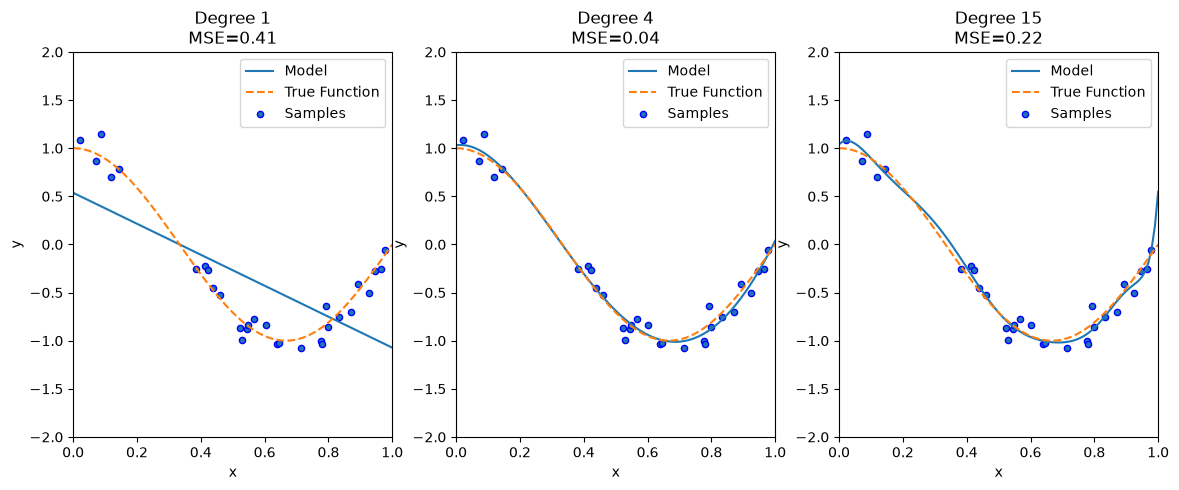

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# 코사인 함수 형태의 그래프를 만들기 위해서
def true_fun(X):
    return np.cos(1.5 * np.pi * X)
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize = (14,5))
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i+1)
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    lr_reg = LinearRegression()
    X_poly = polynomial_features.fit_transform(X.reshape(-1,1), y)
    lr_reg.fit(X_poly, y)
    scores = cross_val_score(lr_reg, X_poly, y, scoring='neg_mean_squared_error', cv=10)

    # 각 회귀계수
    coeff = lr_reg.coef_

    print(f'\nDegree {degrees[i]} 회귀계수는 \n{np.round(coeff, 2)}\n입니다.')
    print(f'MSE는 {-1 * np.mean(scores)}입니다.')

    X_test = np.linspace(0, 1, 100).reshape(-1, 1)
    X_test_poly = polynomial_features.transform(X_test)

    pred = lr_reg.predict(X_test_poly)

    plt.plot(X_test, pred, label = 'Model')
    plt.plot(X_test, true_fun(X_test), '--', label='True Function')
    plt.scatter(X, y, edgecolors='b', s = 20, label = 'Samples')
    plt.xlabel('x');plt.ylabel('y'); plt.xlim((0,1)); plt.ylim((-2, 2)); plt.legend()
    plt.title(f'Degree {degrees[i]}\nMSE={-scores.mean():.2f}')
plt.show()

In [ ]:
# 파이썬의 random과 numpy.random의 차이
import random

# 0에서 1까지 랜덤값
print(random.random())

# 0에서 1까지 랜덤값
print(np.random.rand(10))

# 정규분포 내의 랜덤값
print(np.random.randn(10))

0.811292696948714
[0.01310493 0.51485943 0.55471785 0.68351222 0.40075591 0.52462922
 0.68404322 0.27190788 0.40188729 0.69157859]
[ 0.88845025  0.18123918  1.2788302  -0.6531757  -0.15031148  3.29888449
 -0.15006982  1.06423928  0.29212444 -0.08025634]


In [25]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

# 다항 회귀 모델 사용하기 위한 전처리 (제곱 + 기타 계산)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size = 0.3, random_state = 156
)

# 릿지 모델
ridge = Ridge(alpha=10)

# 학습용 데이터로 학습
ridge.fit(X_train, y_train)

# 검증용 데이터 넣어서 예측
pred = ridge.predict(X_test)
pred_train = ridge.predict(X_train)

# 잔차 제곱 평균, 잔차 제곱 평균 제곱근
mse = mean_squared_error(y_test, pred)
mse_train = mean_squared_error(y_train, pred_train)
rmse = np.sqrt(mse)

print(f'MSE: {mse:.3f}, RMSE: {rmse:.3f}')
print(f"MSE_train: {mse_train:.3F}")
# print(f'Variance score: {r2_score(y_test, pred):.3f}')

ValueError: Expected 2D array, got 1D array instead:
array=[0.0202184  0.07103606 0.0871293  0.11827443 0.14335329 0.38344152
 0.41466194 0.4236548  0.43758721 0.46147936 0.52184832 0.52889492
 0.54488318 0.5488135  0.56804456 0.60276338 0.63992102 0.64589411
 0.71518937 0.77815675 0.78052918 0.79172504 0.79915856 0.83261985
 0.87001215 0.891773   0.92559664 0.94466892 0.96366276 0.97861834].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X, y,scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores,3))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse)) 

In [32]:
from sklearn.linear_model import Lasso
alphas = [0, 0.01, 0.1, 1, 10]
for alpha in alphas :
    lasso = Lasso(alpha = alpha)
    neg_mse_scores = cross_val_score(lasso, X, y, scoring="neg_mean_squared_error", cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
print(f'alpha {alpha} 일 때 5 folds 의 평균 RMSE : {avg_rmse:.3f} ')

alpha 10 일 때 5 folds 의 평균 RMSE : 77.264 


d:\Dev\.venv\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
d:\Dev\.venv\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
d:\Dev\.venv\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
d:\Dev\.venv\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
d:\Dev\.venv\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge wel

In [ ]:
# Ridge
# - L2 규제를 사용한다.
# - 회귀 계수를 0에 가깝게 줄이긴하지만 0으로는 만들지 않는다
# - 독립변수의 중요도를 낮춘다.
# - 다중공선성 문제가 있을 때 사용한다.

# Lasso
# - L1 규제를 사용한다.
# - 회귀 계수를 0으로 만들어버림.
# - 독립변수를 선택한다.
# - 모델의 경량화

# ElasticNet
# - Ridge와 Lasso의 특징을 합쳐놓은 모델


In [20]:
from sklearn.linear_model import ElasticNet

ElasticNet(alpha = 0.1, l1_ratio = 0.5)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [31]:
# 확률적 경사 하강법(SGD) 실습

from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(alpha=0.1, penalty='l2', max_iter=10000)
sgd.fit(X_train, y_train)
pred = sgd.predict(X_test)

mean_squared_error(y_test, pred)


5666.83715739934

# 회귀 트리(Regression Tree)

In [33]:
# 회귀 의사결정나무
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
pred = dt_reg.predict(X_test)

mean_squared_error(y_test, pred)


5731.751879699248

# 앙상블 기법(Ensemble Method)

In [35]:
# 랜덤포레스트 사용법 예시

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
mse_scores = cross_val_score(rf_reg, X, y, scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * mse_scores)
avg_rmse = np.mean(rmse_scores)
print(' 5 교차 검증의 개별 Negative MSE scores: ', np.round(mse_scores, 2))
print(' 5 교차 검증의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(f' 5 교차 검증의 평균 RMSE : {avg_rmse:.3f} ')

 5 교차 검증의 개별 Negative MSE scores:  [-2994.11 -3112.26 -3547.44 -3272.69 -3709.92]
 5 교차 검증의 개별 RMSE scores :  [54.72 55.79 59.56 57.21 60.91]
 5 교차 검증의 평균 RMSE : 57.637 
